# 06 – Baseline Model Development

In this notebook, we train and evaluate initial baseline models on the balanced dataset:

1. Logistic Regression with PCA (Dimensionality Reduction)
2. Logistic Regression with LASSO (Feature Selection)
3. Decision Tree Classifier

Each model is evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC metrics.


In [2]:
%pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 16.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=ee553eb3e894553681479e2f1a664625fc066927739596ed8eddfb30cde5531d
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [3]:
# --- Import libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, roc_curve,
    brier_score_loss
)
import joblib

In [5]:
# --- Mount Drive and set paths ---
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/classification_project'
data_path = f'{base_path}/data'
results_path = f'{base_path}/results'
models_path = f'{base_path}/models'
os.makedirs(results_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)

Mounted at /content/drive


In [6]:
# --- Load balanced dataset ---
file_path = f'{data_path}/05_balanced_cirrhosis.csv'
data = pd.read_csv(file_path)
print(f"Dataset loaded from: {file_path}")
print("Shape:", data.shape)

Dataset loaded from: /content/drive/MyDrive/classification_project/data/05_balanced_cirrhosis.csv
Shape: (514, 19)


### Train-Test Split

We split the dataset into 80% training and 20% testing sets using stratified sampling.


In [7]:
# --- Split features and labels ---
X = data.drop(columns=['Status'])
y = data['Status']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Data Standardization
Before PCA or LASSO, we standardize features to improve model convergence.


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===================================================================

# Helper: Performance summary

In [14]:
def evaluate_model(model, X_t, y_t, model_name):
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:,1]
    print(f"\n=== {model_name} ===")
    print(classification_report(y_t, y_pred))
    auc = roc_auc_score(y_t, y_prob)
    print(f"ROC-AUC: {auc:.3f}")

    # Confusion matrix
    conf = confusion_matrix(y_t, y_pred)
    sns.heatmap(conf, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Censored','Death'],
                yticklabels=['Censored','Death'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.savefig(f"{results_path}/06_{model_name}_confusion.png", bbox_inches='tight')
    plt.show()

    # ROC
    fpr,tpr,_=roc_curve(y_t,y_prob)
    plt.plot(fpr,tpr,label=f"AUC={auc:.2f}")
    plt.plot([0,1],[0,1],'--',color='red')
    plt.legend(); plt.title(f'{model_name} - ROC Curve')
    plt.savefig(f"{results_path}/06_{model_name}_roc.png", bbox_inches='tight')
    plt.show()

    # Calibration
    prob_true, prob_pred = calibration_curve(y_t, y_prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o')
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.title(f'{model_name} - Calibration Curve')
    plt.xlabel('Mean predicted probability'); plt.ylabel('Fraction of positives')
    plt.savefig(f"{results_path}/06_{model_name}_calibration.png", bbox_inches='tight')
    plt.show()
    brier = brier_score_loss(y_t, y_prob)
    print(f"Brier Score: {brier:.4f}")
    return auc, brier

### Logistic Regression – PCA Reduction
We apply PCA to retain 95% of variance, then train a logistic regression model on reduced features.



=== LogReg_PCA ===
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        52
           1       0.87      0.80      0.84        51

    accuracy                           0.84       103
   macro avg       0.85      0.84      0.84       103
weighted avg       0.85      0.84      0.84       103

ROC-AUC: 0.903


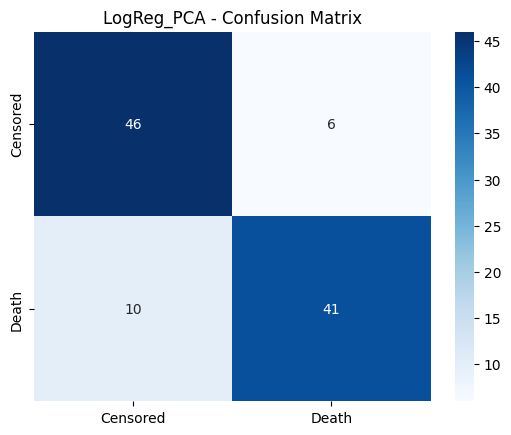

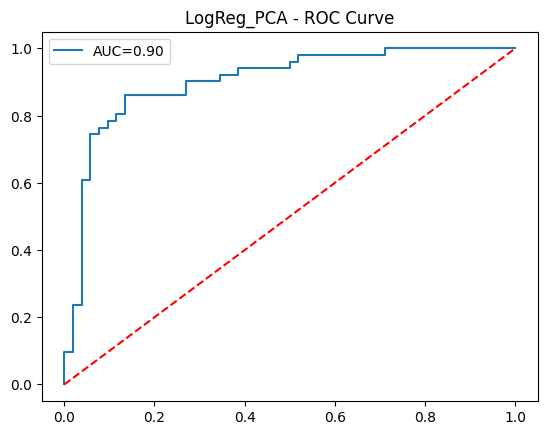

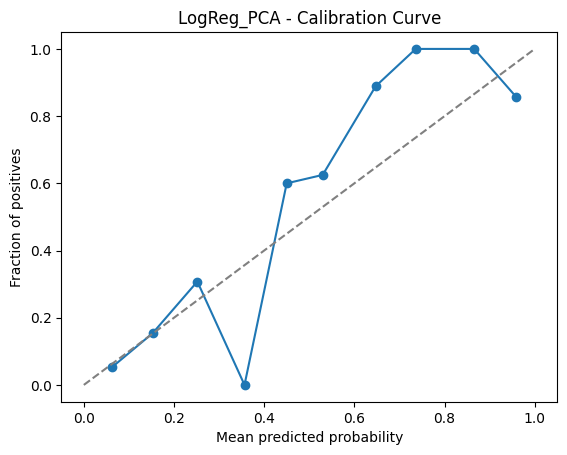

Brier Score: 0.1268


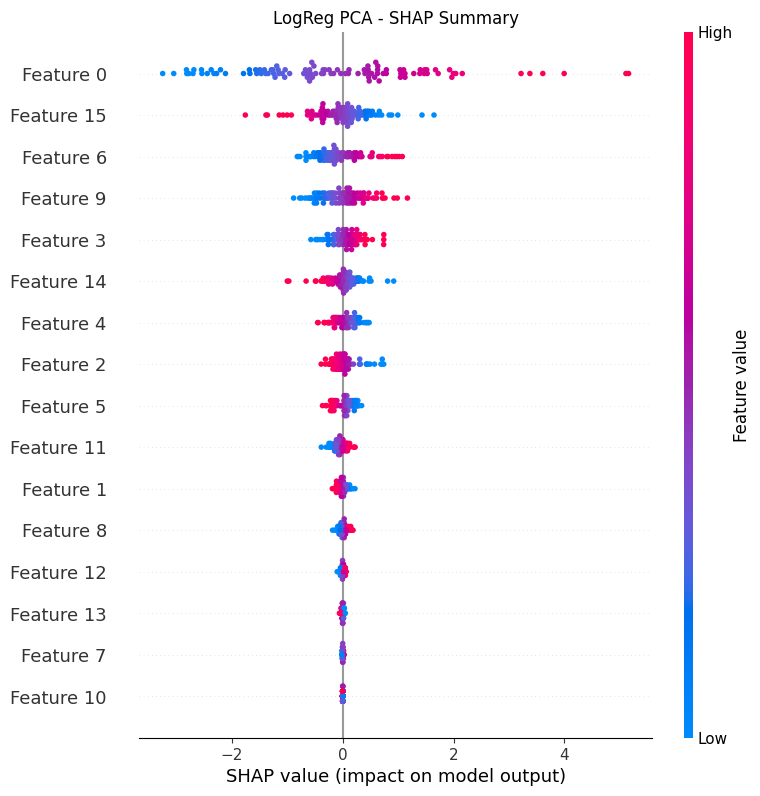

In [15]:
# --- Logistic Regression with PCA ---
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
log_pca = LogisticRegression(random_state=42)
log_pca.fit(X_train_pca, y_train)
auc_pca, brier_pca = evaluate_model(log_pca, X_test_pca, y_test, "LogReg_PCA")
joblib.dump(log_pca, f"{models_path}/logistic_pca.pkl")

# SHAP for PCA model (approximate)
explainer_pca = shap.Explainer(log_pca, X_train_pca)
shap_values_pca = explainer_pca(X_test_pca)
shap.summary_plot(shap_values_pca, show=False)
plt.title("LogReg PCA - SHAP Summary")
plt.savefig(f"{results_path}/06_LogReg_PCA_SHAP.png", bbox_inches='tight')
plt.show()

### Logistic Regression – LASSO Regularization
We use L1 penalty to perform automatic feature selection and interpret important predictors.



=== LogReg_LASSO ===
              precision    recall  f1-score   support

           0       0.81      0.92      0.86        52
           1       0.91      0.78      0.84        51

    accuracy                           0.85       103
   macro avg       0.86      0.85      0.85       103
weighted avg       0.86      0.85      0.85       103

ROC-AUC: 0.914


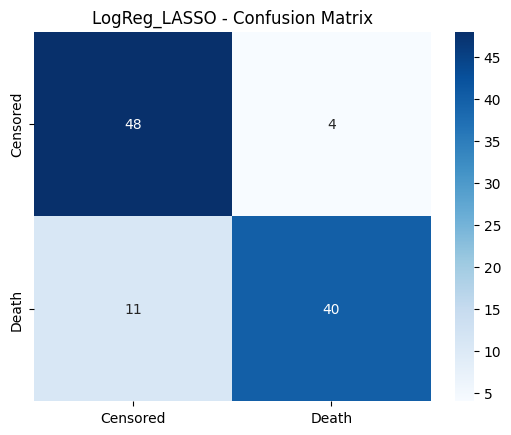

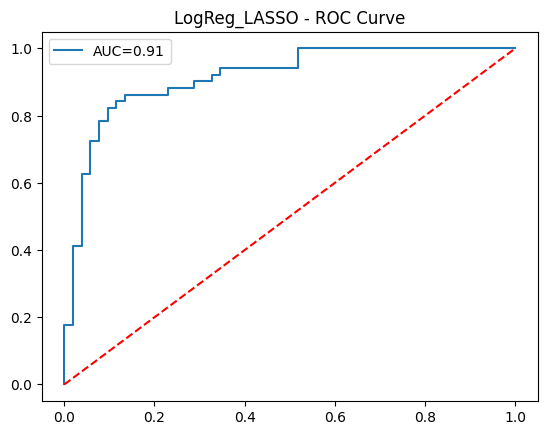

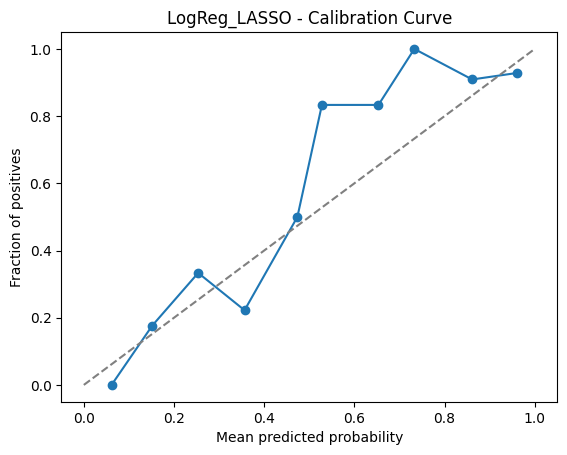

Brier Score: 0.1226


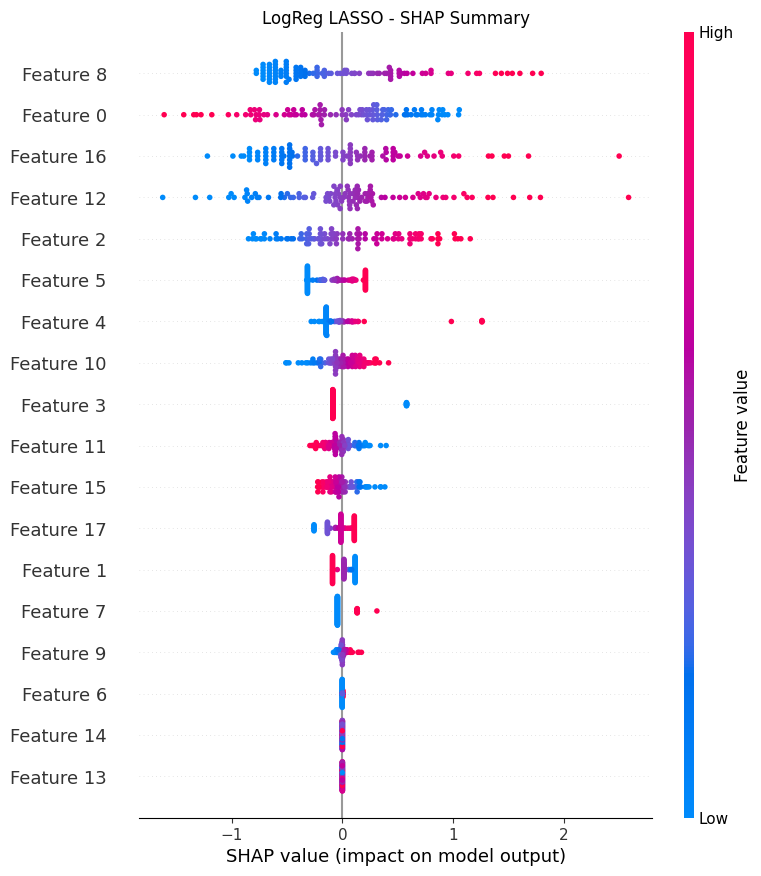

In [16]:
# --- Logistic Regression with LASSO ---
log_lasso = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
log_lasso.fit(X_train_scaled, y_train)
auc_lasso, brier_lasso = evaluate_model(log_lasso, X_test_scaled, y_test, "LogReg_LASSO")
joblib.dump(log_lasso, f"{models_path}/logistic_lasso.pkl")

# LIME explanation
lime_exp = LimeTabularExplainer(
    X_train_scaled, feature_names=X.columns, class_names=['Censored','Death'],
    mode='classification'
)
exp = lime_exp.explain_instance(X_test_scaled[0], log_lasso.predict_proba)
exp.save_to_file(f"{results_path}/06_LogReg_LASSO_LIME.html")

# SHAP summary
explainer_lasso = shap.Explainer(log_lasso, X_train_scaled)
shap_values_lasso = explainer_lasso(X_test_scaled)
shap.summary_plot(shap_values_lasso, X_test, show=False)
plt.title("LogReg LASSO - SHAP Summary")
plt.savefig(f"{results_path}/06_LogReg_LASSO_SHAP.png", bbox_inches='tight')
plt.show()

### Decision Tree Classifier
A simple non-linear baseline model used to capture feature interactions.



=== Decision_Tree ===
              precision    recall  f1-score   support

           0       0.81      0.90      0.85        52
           1       0.89      0.78      0.83        51

    accuracy                           0.84       103
   macro avg       0.85      0.84      0.84       103
weighted avg       0.85      0.84      0.84       103

ROC-AUC: 0.844


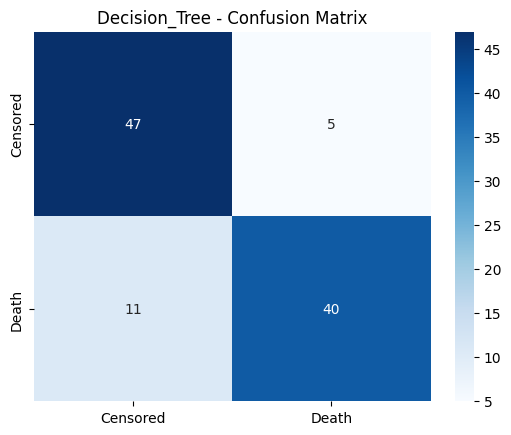

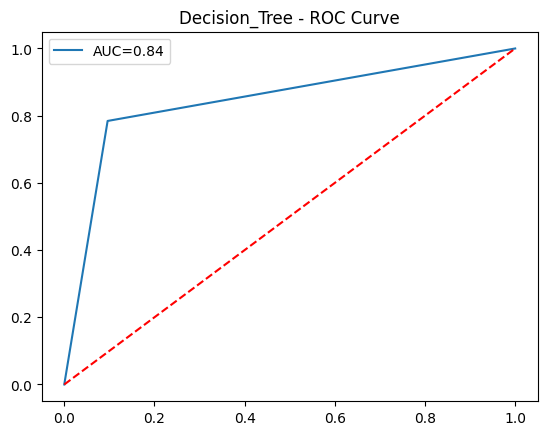

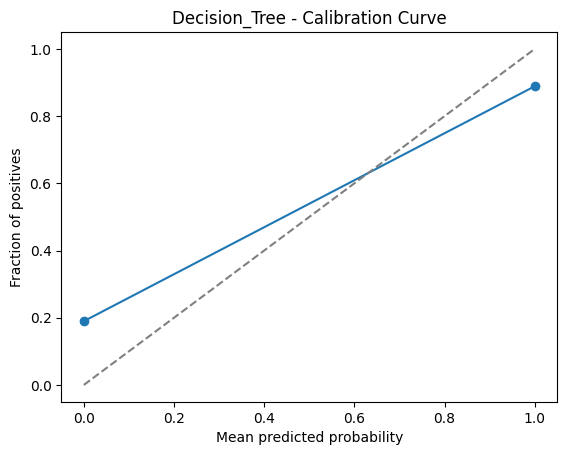

Brier Score: 0.1553


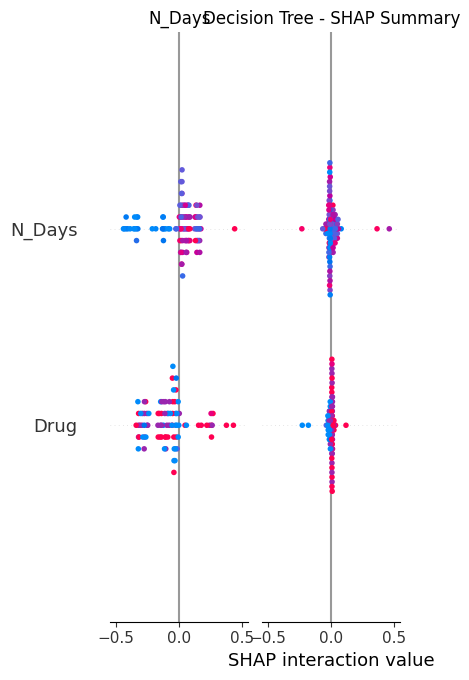

In [17]:
# --- Decision Tree ---
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)
auc_tree, brier_tree = evaluate_model(tree, X_test, y_test, "Decision_Tree")
joblib.dump(tree, f"{models_path}/decision_tree.pkl")

# SHAP for tree model
explainer_tree = shap.Explainer(tree, X_train)
shap_values_tree = explainer_tree(X_test)
shap.summary_plot(shap_values_tree, X_test, show=False)
plt.title("Decision Tree - SHAP Summary")
plt.savefig(f"{results_path}/06_DecisionTree_SHAP.png", bbox_inches='tight')
plt.show()

In [18]:
# --- Summary Table ---
summary = pd.DataFrame({
    'Model':['LogReg_PCA','LogReg_LASSO','Decision_Tree'],
    'ROC_AUC':[auc_pca, auc_lasso, auc_tree],
    'Brier_Score':[brier_pca, brier_lasso, brier_tree]
})
summary.to_csv(f"{results_path}/06_baseline_summary.csv", index=False)
display(summary)
print(f"Baseline results saved to {results_path}")

,Model,ROC_AUC,Brier_Score
0,LogReg_PCA,0.902715,0.126791
1,LogReg_LASSO,0.914404,0.122571
2,Decision_Tree,0.844080,0.155340


Baseline results saved to /content/drive/MyDrive/classification_project/results


### Notes
- Logistic Regression with PCA → focuses on variance reduction, yielding smoother decision boundaries.  
- LASSO Regression → performs embedded feature selection for interpretability.  
- Decision Tree → captures non-linear patterns but may overfit on small data.  

These models serve as **baselines** for comparison with ensemble and advanced models later.


**Next Notebook:** [07_Model_Development_Intermediate_Explainability.ipynb](07_Model_Development_Intermediate_Explainability.ipynb)

We will train an ensemble model (Random Forest) and introduce model explainability using SHAP values.
